<a href="https://colab.research.google.com/github/marefuabebe/Machine-Learning-Regression-Models-using-House-Price-Dataset/blob/main/Machine_Learning_Regression_Models_using_House_Price_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Importing Libraries



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

 Metrics to evaluate model performance.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

Decision Tree regression predicts house price using a tree of rules (if-else conditions).Example: if area > 2000 & bedrooms >=3 → price is high, else medium.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

 K-Nearest Neighbors regression predicts house price based on similar houses.Example: uses the average price of the 5 nearest houses with similar features.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

 PolynomialFeatures: Used to transform features for polynomial regression (curved relationships).Example: price might grow faster with area in a non-linear way. StandardScaler: Scales features to have mean 0 and variance 1

In [ ]:
from sklearn.linear_model import LinearRegression

Linear Regression model predicts a continuous target (house price) using one or multiple features. Example: predict price based on area, bedrooms, bathrooms, etc.

In [ ]:
from sklearn.model_selection import train_test_split

Splits the dataset into training and testing sets.Example: 80% data to train the model, 20% to test its prediction.

In [ ]:
import matplotlib.pyplot as plt

Matplotlib is used for plotting graphs and visualizing data.Example: plot house price distribution, scatter plots of features vs. price.

In [ ]:
from sklearn.tree import plot_tree


Used to visualize the structure of the trained Decision Tree model

In [ ]:
import numpy as np

NumPy is used for numerical computations, arrays, and mathematical operations. Example: handling house features like area, bedrooms, etc.

In [ ]:
import pandas as pd

 Pandas is used to read and manipulate datasets in tabular form. Example: reading 'Housing Price.csv' and selecting features and target column

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/softwareWCU/Machine-Learning-Regression-Models-using-House-Price-Dataset/main/Housing%20Price.csv"

df = pd.read_csv(url)
df.head()



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:

df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


The dataset is split into input features (X) by removing the target column and the target variable (y), which contains the house price to be predicted.X contains all input features (house characteristics)
We remove 'price' because it is the target we want to predict .axis=1 means we are removing a COLUMN, not a row.y contains the target variable
This is the house price that the model will learn to predict

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

Binary features with "yes/no" values are converted into numeric 1/0 format. The categorical feature 'furnishingstatus' is transformed using One-Hot Encoding.because it has multiple categories with no natural order.One category is dropped to avoid multicollinearity issues.

In [ ]:
binary_cols = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning', 'prefarea'
]

df[binary_cols] = df[binary_cols].apply(
    lambda x: x.map({'yes': 1, 'no': 0})
)

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df = df.astype(int)

# Define X and y AFTER preprocessing df
X = df.drop('price', axis=1)
y = df['price']

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


Split data into training and testing sets
X = input features, y = target (house price)
test_size=0.2 → 80% training, 20% testing
random_state=42 → same split every time for fair comparison

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


StandardScaler makes all features have similar scale.This helps distance-based models like KNN

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Linear Regression model

In [ ]:

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)



LinearRegression()

Train Multiple Linear Regression model

In [ ]:

mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)


LinearRegression()

Train Polynomial Regression

> Create polynomial features (degree 2)

>Generate polynomial features from scaled training data

> Train Polynomial Regression model



In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)

LinearRegression()

 Train KNN Regression model

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor()

Train Decision Tree Regression model

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

# PREDICTION & EVALUATION code for all 5 models

Predict house prices using Linear Regression and Evaluate Linear Regression model

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression
MAE: 970043.4039201642
MSE: 1754318687330.668
RMSE: 1324506.9600914402
R2 Score: 0.6529242642153176


Predict house prices using Multiple Linear Regression and Evaluate Multiple Linear Regression model

In [ ]:

y_pred_mlr = mlr.predict(X_test_scaled)
print("Multiple Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_mlr))
print("MSE:", mean_squared_error(y_test, y_pred_mlr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mlr)))
print("R2 Score:", r2_score(y_test, y_pred_mlr))


Multiple Linear Regression
MAE: 970043.4039201642
MSE: 1754318687330.668
RMSE: 1324506.9600914402
R2 Score: 0.6529242642153176


Predict house prices using Polynomial Regression and Evaluate Polynomial Regression model and Transform scaled test data into polynomial features

In [ ]:
X_test_poly = poly.transform(X_test_scaled)
y_pred_poly = poly_lr.predict(X_test_poly)
print("Polynomial Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print("R2 Score:", r2_score(y_test, y_pred_poly))

Polynomial Regression
MAE: 1034749.2706758833
MSE: 1901686413946.449
RMSE: 1379016.466162188
R2 Score: 0.6237689217365154


Predict house prices using KNN Regression and Evaluate KNN Regression model

In [ ]:

y_pred_knn = knn.predict(X_test_scaled)
print("KNN Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R2 Score:", r2_score(y_test, y_pred_knn))


KNN Regression
MAE: 999594.6055045872
MSE: 1953996997258.202
RMSE: 1397854.4263471079
R2 Score: 0.6134197563748457


Predict house prices using Decision Tree Regression and Evaluate Decision Tree Regression model

In [ ]:

y_pred_dt = dt.predict(X_test)
print("Decision Tree Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))


Decision Tree Regression
MAE: 1195266.0550458715
MSE: 2642802637614.6787
RMSE: 1625669.904259373
R2 Score: 0.4771459275854347


#visualization
>Create Results DataFrame (with MAE, MSE, RMSE, R²)

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Multiple Linear Regression',
        'Polynomial Regression',
        'KNN Regression',
        'Decision Tree Regression'
    ],
    'MAE': [
        970043.4039201642,
        970043.4039201642,
        1034749.2706758833,
        999594.6055045872,
        1195266.0550458715
    ],
    'MSE': [
        1754318687330.668,
        1754318687330.668,
        1901686413946.449,
        1953996997258.202,
        2642802637614.6787
    ],
    'RMSE': [
        1324506.9600914402,
        1324506.9600914402,
        1379016.466162188,
        1397854.4263471079,
        1625669.904259373
    ],
    'R2 Score': [
        0.6529242642153176,
        0.6529242642153176,
        0.6237689217365154,
        0.6134197563748457,
        0.4771459275854347
    ]
})

results


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,Multiple Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
2,Polynomial Regression,1.034749e+06,1.901686e+12,1.379016e+06,0.623769
3,KNN Regression,9.995946e+05,1.953997e+12,1.397854e+06,0.613420
4,Decision Tree Regression,1.195266e+06,2.642803e+12,1.625670e+06,0.477146


Visualization – R² Score Comparison

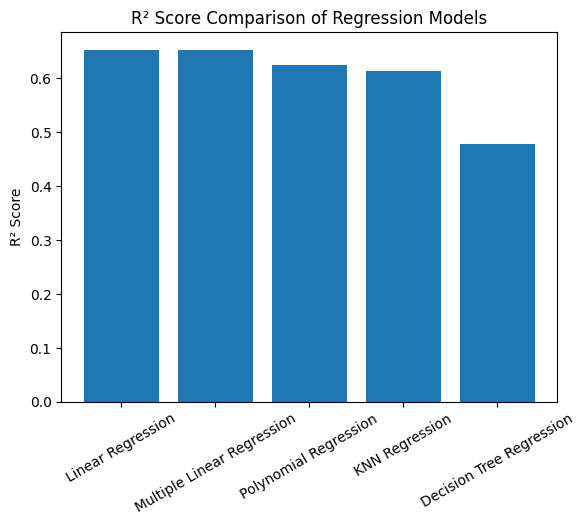

In [ ]:
plt.figure()
plt.bar(results['Model'], results['R2 Score'])
plt.title('R² Score Comparison of Regression Models')
plt.xticks(rotation=30)
plt.ylabel('R² Score')
plt.show()



Visualization – RMSE Comparison (Lower is Better)

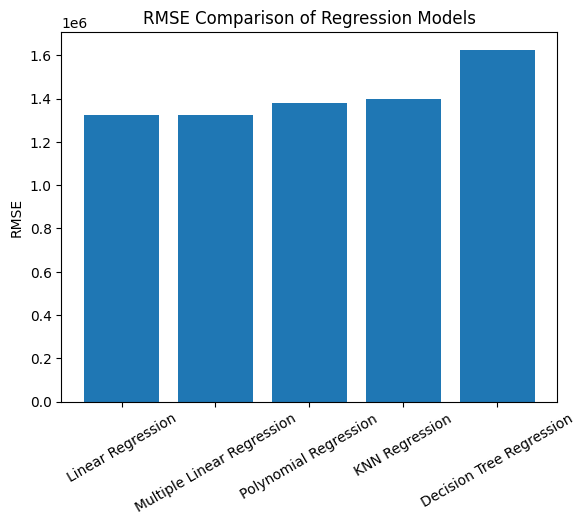

In [ ]:
plt.figure()
plt.bar(results['Model'], results['RMSE'])
plt.title('RMSE Comparison of Regression Models')
plt.xticks(rotation=30)
plt.ylabel('RMSE')
plt.show()


Visualization – MSE Comparison

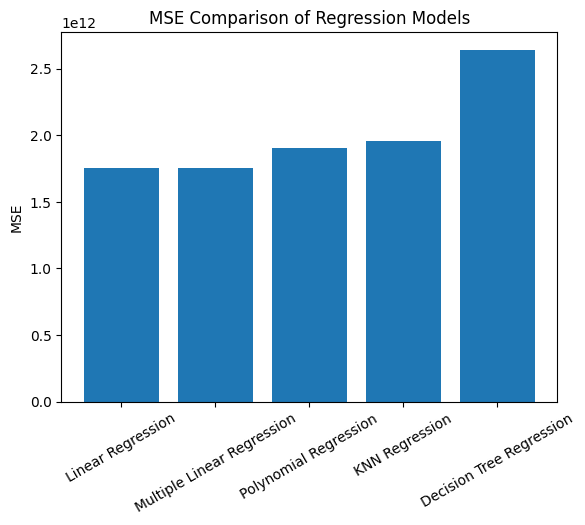

In [ ]:
plt.figure()
plt.bar(results['Model'], results['MSE'])
plt.title('MSE Comparison of Regression Models')
plt.xticks(rotation=30)
plt.ylabel('MSE')
plt.show()


Final Conclusion (based on visuals)

Multiple Linear Regression performs the best overall
It has the highest R² score and the lowest error values
Polynomial and KNN perform reasonably well
Decision Tree performs the worst due to overfitting


Install Graphviz system package required for Decision Tree visualization AND Install Python Graphviz library to render the Decision Tree as SVG

In [ ]:
!apt-get install graphviz
!pip install graphviz


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


 Used to export the trained Decision Tree model into a visual graph format AND Used to display the exported Decision Tree graph as an SVG image

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

Export the trained Decision Tree model into DOT format for visualization AND Render and display the Decision Tree as a scalable SVG image

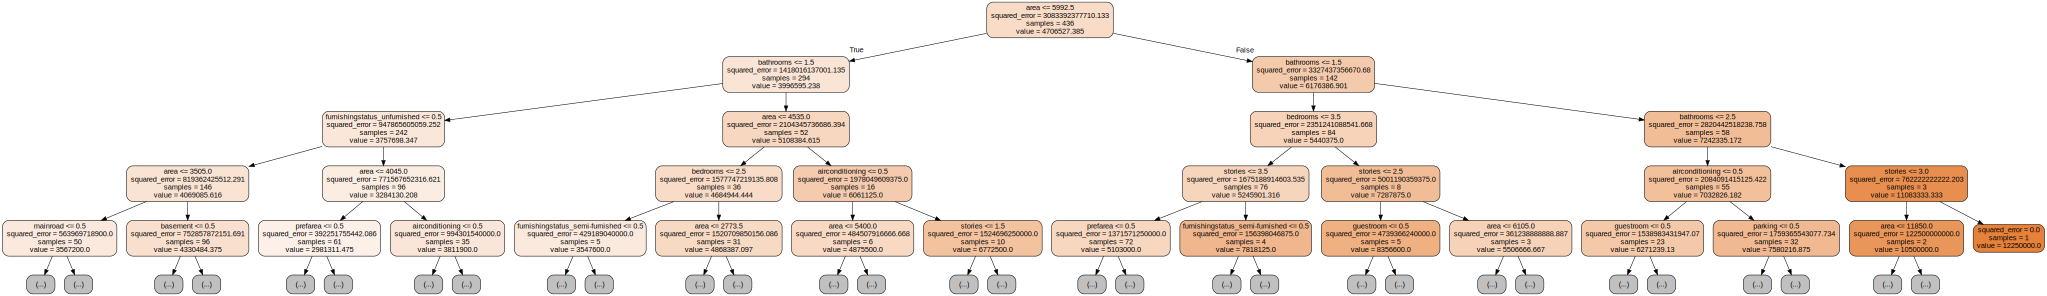

In [ ]:
dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=4
)

graph = graphviz.Source(dot_data, format="svg")
graph


                  # Overall Conclusion:
 Five regression models (Linear, Multiple Linear, Polynomial, KNN, and Decision Tree) were trained and evaluated using MAE, MSE, RMSE, and R² score. Among all models, Multiple Linear Regression performed the best, achieving the lowest error values (MAE and RMSE) and the highest R² score (~0.65),meaning it explained about 65% of the variation in house prices.Polynomial and KNN Regression showed reasonable performance but were slightly less accurate. Decision Tree Regression performed the worst, likely due to overfitting and poor generalization.Therefore, Multiple Linear Regression was selected as the most suitable model for predicting house prices in this dataset.


Create ONE unseen house sample

In [ ]:

unseen_data = pd.DataFrame({
    'area': [7420],
    'bedrooms': [4],
    'bathrooms': [2],
    'stories': [2],
    'mainroad': [1],
    'guestroom': [0],
    'basement': [1],
    'hotwaterheating': [0],
    'airconditioning': [1],
    'parking': [2],
    'prefarea': [1],
    'furnishingstatus_semi-furnished': [0],
    'furnishingstatus_unfurnished': [1]
})


Scale unseen data

---



In [ ]:
unseen_scaled = scaler.transform(unseen_data)

Linear Regression / Multiple Linear Regression

In [ ]:
pred_lr = lr.predict(unseen_scaled)[0]
pred_mlr = mlr.predict(unseen_scaled)[0]




Polynomial Regression

In [ ]:
unseen_poly = poly.transform(unseen_scaled)
pred_poly = poly_lr.predict(unseen_poly)[0]


KNN Regression

In [ ]:
pred_knn = knn.predict(unseen_scaled)[0]


Decision Tree Regression

In [ ]:
pred_dt = dt.predict(unseen_data)[0]


Show predictions clearly

In [ ]:
predictions = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Multiple Linear Regression',
        'Polynomial Regression',
        'KNN Regression',
        'Decision Tree Regression'
    ],
    'Predicted Price': [
        pred_lr,
        pred_mlr,
        pred_poly,
        pred_knn,
        pred_dt
    ]
})

predictions


,Model,Predicted Price
0,Linear Regression,7.537406e+06
1,Multiple Linear Regression,7.537406e+06
2,Polynomial Regression,8.731421e+06
3,KNN Regression,7.721000e+06
4,Decision Tree Regression,9.100000e+06


 # Overall Conclusion:

Linear and Multiple Linear Regression give the same and most stable prediction (≈ 7.54 million), showing consistent behavior.
KNN and Polynomial Regression predict slightly higher prices, indicating moderate variation.
Decision Tree Regression gives the highest value (≈ 9.10 million) and may overestimate due to overfitting.

👉 Multiple Linear Regression is the most dependable model for this unseen data.